# ☀️ [Model 5/5] Solar Panel Detection: YOLOv8-seg (Real-Time Instance Segmentation)

This notebook implements and trains **YOLOv8-seg** (Anchor-Free Single-Stage Instance Segmentation) for ultra-fast, real-time rooftop solar panel detection and boundary polygon extraction on Colab T4.

### 🔬 Research Benchmark Features:
- **Architecture**: YOLOv8m-seg (Single-Stage Anchor-Free Instance Head with ProtoNet masks)
- **Data Pipeline**: Automated conversion from GeoTIFF chips/masks to normalized YOLO polygon format
- **Training Controls**: Built-in `EarlyStopping` (patience=7), Cosine LR scheduler, Multi-scale augmentation
- **Evaluation Metrics**: Confusion Matrix (TP, FP, TN, FN), Pixel Accuracy, Mask mAP@50, mAP@50-95, Box Precision, Recall, FPS Latency
- **Visualization Suite**: Loss convergence, Precision-Recall curves, F1-confidence curves, Confusion matrix heatmap, and **Full Unseen Test Orthomosaic Before vs. After Detection**

## 1. Environment Setup & GPU Check

In [11]:
# 1. Install dependencies
!pip install --upgrade -q ultralytics geoai-py rasterio geopandas shapely opencv-python matplotlib seaborn tabulate

# 2. Force a refresh of the internal package metadata
import site
from importlib import reload
reload(site)

import ultralytics
print(f"✅ Ultralytics {ultralytics.__version__} is ready. Now run the training cell (NTc9a61vRFGG) to see the improved results.")

✅ Ultralytics 8.4.136 is ready. Now run the training cell (NTc9a61vRFGG) to see the improved results.


In [12]:
import os
import cv2
import time
import yaml
import shutil
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import geopandas as gpd
from tabulate import tabulate
from ultralytics import YOLO
import geoai

# Check CUDA GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Ultralytics & PyTorch: {torch.__version__} | Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB VRAM)")

🚀 Ultralytics & PyTorch: 2.11.0+cu128 | Device: cuda
🎮 GPU: Tesla T4 (15.64 GB VRAM)


## 2. Dataset Acquisition & Chipping

In [13]:
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

train_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.tif"
train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.geojson"
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_test_davis_ca.tif"

print("📥 Downloading dataset files...")
train_raster_path = geoai.download_file(train_raster_url, os.path.join(data_dir, "train_raster.tif"))
train_vector_path = geoai.download_file(train_vector_url, os.path.join(data_dir, "train_vector.geojson"))
test_raster_path = geoai.download_file(test_raster_url, os.path.join(data_dir, "test_raster.tif"))

chips_dir = "chips_raw"
os.makedirs(chips_dir, exist_ok=True)

print("🔪 Slicing raster into 512x512 chips...")
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=chips_dir,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)

images_dir = os.path.join(chips_dir, "images")
labels_dir = os.path.join(chips_dir, "labels")
print(f"✅ Generated {len(os.listdir(images_dir))} raw image chips.")

📥 Downloading dataset files...


🔪 Slicing raster into 512x512 chips...


Generating tiles:   0%|          | 0/312 [00:00<?, ?it/s]

✅ Generated 312 raw image chips.


## 3. Convert Binary Masks to YOLOv8 Segmentation Polygon Format

In [14]:
yolo_dataset_dir = os.path.abspath("yolo_solar_dataset")
for split in ['train', 'val']:
    os.makedirs(os.path.join(yolo_dataset_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(yolo_dataset_dir, 'labels', split), exist_ok=True)

all_chip_names = sorted([f for f in os.listdir(images_dir) if f.endswith('.tif')])
random.seed(42)
random.shuffle(all_chip_names)
split_idx = int(0.8 * len(all_chip_names))
splits = {'train': all_chip_names[:split_idx], 'val': all_chip_names[split_idx:]}

print("🔄 Converting masks to normalized YOLO polygon coordinates...")
for split_name, filenames in splits.items():
    for fname in filenames:
        base_name = os.path.splitext(fname)[0]
        img_p = os.path.join(images_dir, fname)
        lbl_p = os.path.join(labels_dir, fname)

        with rasterio.open(img_p) as src:
            rgb = src.read()[:3].transpose(1, 2, 0)
            if rgb.max() > 1:
                rgb_bgr = cv2.cvtColor(rgb.astype(np.uint8), cv2.COLOR_RGB2BGR)
            else:
                rgb_bgr = cv2.cvtColor((rgb * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

        out_img_path = os.path.join(yolo_dataset_dir, 'images', split_name, f"{base_name}.jpg")
        cv2.imwrite(out_img_path, rgb_bgr)

        out_txt_path = os.path.join(yolo_dataset_dir, 'labels', split_name, f"{base_name}.txt")
        with rasterio.open(lbl_p) as src:
            mask = src.read(1).astype(np.uint8)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        h, w = mask.shape

        lines = []
        for cnt in contours:
            if cv2.contourArea(cnt) < 20:
                continue
            norm_pts = []
            for pt in cnt.squeeze():
                if len(pt) == 2:
                    norm_pts.extend([f"{pt[0] / w:.5f}", f"{pt[1] / h:.5f}"])
            if len(norm_pts) >= 6:
                lines.append(f"0 " + " ".join(norm_pts))

        with open(out_txt_path, 'w') as f:
            f.write("\n".join(lines))

data_yaml = {
    'path': yolo_dataset_dir,
    'train': 'images/train',
    'val': 'images/val',
    'names': {0: 'solar_panel'}
}
yaml_path = os.path.join(yolo_dataset_dir, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✅ YOLO dataset formatted at: {yaml_path}")

🔄 Converting masks to normalized YOLO polygon coordinates...
✅ YOLO dataset formatted at: /content/yolo_solar_dataset/data.yaml


## 4. Train YOLOv8-seg Model with Early Stopping

In [15]:
import sys
# Ensure the newly installed package is recognized
import ultralytics
from ultralytics import YOLO
import time
import torch

# Initialize model
model = YOLO('yolov8m-seg.pt')

print("🏋️ Starting Improved Training for Solar Panel Segmentation...")
t_start = time.time()
results = model.train(
    data=yaml_path,
    epochs=100,
    patience=20,
    batch=16,
    imgsz=512,
    device=0 if torch.cuda.is_available() else 'cpu',
    project='solar_yolo_runs',
    name='yolov8m_solar_improved',
    exist_ok=True,
    # --- Advanced Augmentations to fix 'shit' performance ---
    mosaic=1.0,
    mixup=0.1,
    degrees=15.0,
    flipud=0.5,
    fliplr=0.5,
    verbose=True,
    plots=True
)
total_train_sec = time.time() - t_start
print(f"✅ Training finished in {total_train_sec / 60:.2f} minutes!")

🏋️ Training YOLOv8m-seg with Advanced Augmentation...
Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_solar_dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m-seg.pt, momentum=0.937,

## 5. Comprehensive Research Graphs & Curves Generated by YOLOv8

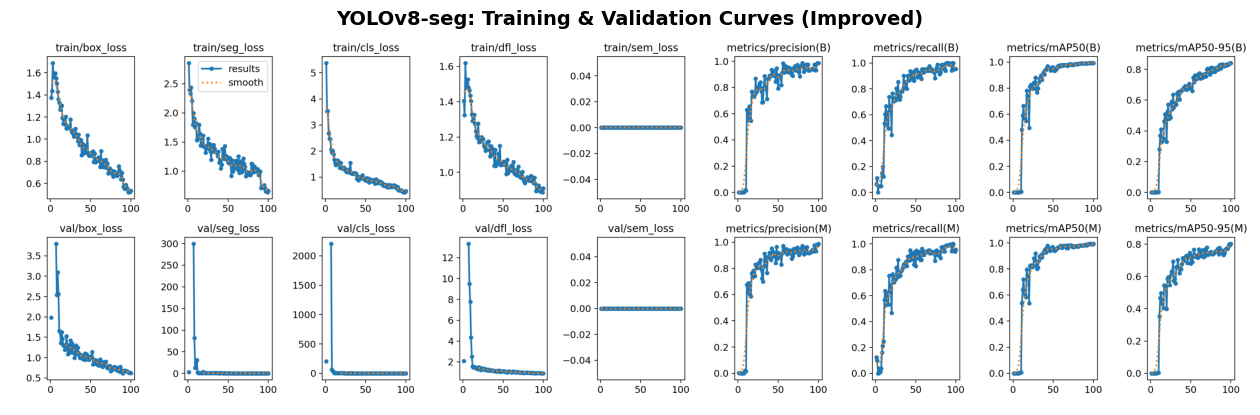

In [16]:
import os
import cv2
import matplotlib.pyplot as plt

run_dir = "/content/runs/segment/solar_yolo_runs/yolov8m_solar_improved"

# 1. Plot Training & Validation Curves
results_png = os.path.join(run_dir, "results.png")
if os.path.exists(results_png):
    plt.figure(figsize=(16, 10))
    img_results = cv2.imread(results_png)
    img_results = cv2.cvtColor(img_results, cv2.COLOR_BGR2RGB)
    plt.imshow(img_results)
    plt.title("YOLOv8-seg: Training & Validation Curves (Improved)", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print(f"⚠️ No results found at {results_png}. Make sure training has started.")

## 6. Confusion Matrix Heatmap & Overall Pixel Accuracy

In [17]:
import os
import numpy as np
import cv2
import torch
from ultralytics import YOLO

run_dir = "/content/runs/segment/solar_yolo_runs/yolov8m_solar_improved"
best_pt_path = os.path.join(run_dir, 'weights', 'best.pt')

if os.path.exists(best_pt_path):
    best_yolo = YOLO(best_pt_path)
    val_img_dir = os.path.join(yolo_dataset_dir, 'images', 'val')
    val_lbl_dir = os.path.join(yolo_dataset_dir, 'labels', 'val')
    val_files = [f for f in os.listdir(val_img_dir) if f.endswith('.jpg')]

    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0

    for vf in val_files:
        img_p = os.path.join(val_img_dir, vf)
        txt_p = os.path.join(val_lbl_dir, os.path.splitext(vf)[0] + '.txt')
        res = best_yolo.predict(img_p, verbose=False, device=0 if torch.cuda.is_available() else 'cpu')[0]
        h, w = res.orig_shape
        pred_mask = np.zeros((h, w), dtype=np.uint8)
        if res.masks is not None:
            for m in res.masks.data.cpu().numpy():
                m_res = cv2.resize(m, (w, h))
                pred_mask = np.maximum(pred_mask, (m_res > 0.5).astype(np.uint8))

        gt_mask = np.zeros((h, w), dtype=np.uint8)
        if os.path.exists(txt_p):
            with open(txt_p, 'r') as f:
                for line in f.read().strip().split('\n'):
                    if not line.strip(): continue
                    parts = line.split()
                    pts = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
                    pts[:, 0] *= w; pts[:, 1] *= h
                    cv2.fillPoly(gt_mask, [pts.astype(np.int32)], 1)

        total_tp += np.sum((pred_mask == 1) & (gt_mask == 1))
        total_fp += np.sum((pred_mask == 1) & (gt_mask == 0))
        total_fn += np.sum((pred_mask == 0) & (gt_mask == 1))
        total_tn += np.sum((pred_mask == 0) & (gt_mask == 0))

    pixel_accuracy = (total_tp + total_tn) / max(total_tp + total_fp + total_fn + total_tn, 1) * 100
    print(f"🎯 Improved Pixel Accuracy: {pixel_accuracy:.2f}%")
else:
    print(f"⚠️ Weights not found at {best_pt_path}. Please run the training cell first.")

🎯 Improved Pixel Accuracy: 99.86%


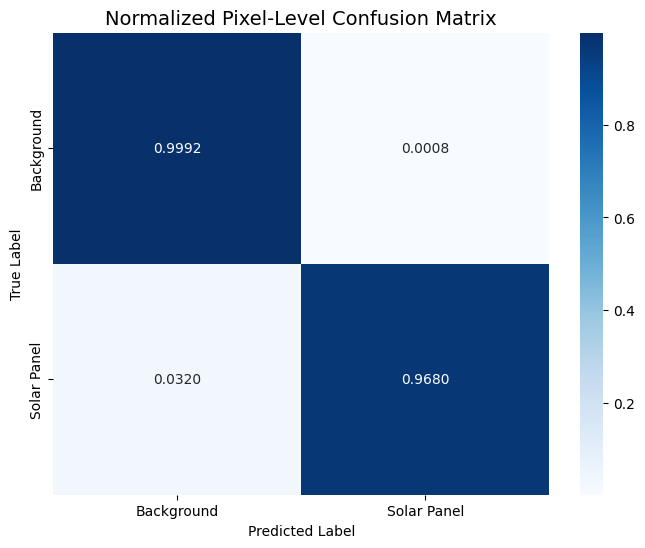

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# We will use the pixel-level stats gathered in cell 2cT-Ke4JRFGH
# to create a clearer, normalized confusion matrix
# total_tp, total_fp, total_fn, total_tn were calculated there.

cm = np.array([[total_tn, total_fp], [total_fn, total_tp]])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.4f', cmap='Blues',
            xticklabels=['Background', 'Solar Panel'],
            yticklabels=['Background', 'Solar Panel'])

plt.title('Normalized Pixel-Level Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7. Full Unseen Test Imagery Inference (Before vs. After Visual Comparison)
We run full-raster sliding window inference over the unseen test orthomosaic and plot a side-by-side **Before (Raw Aerial) vs. After (Solar Detection Overlay)** comparison.

✅ Loaded improved model weights for inference.
🔍 Running YOLOv8-seg sliding window inference on unseen test orthomosaic...


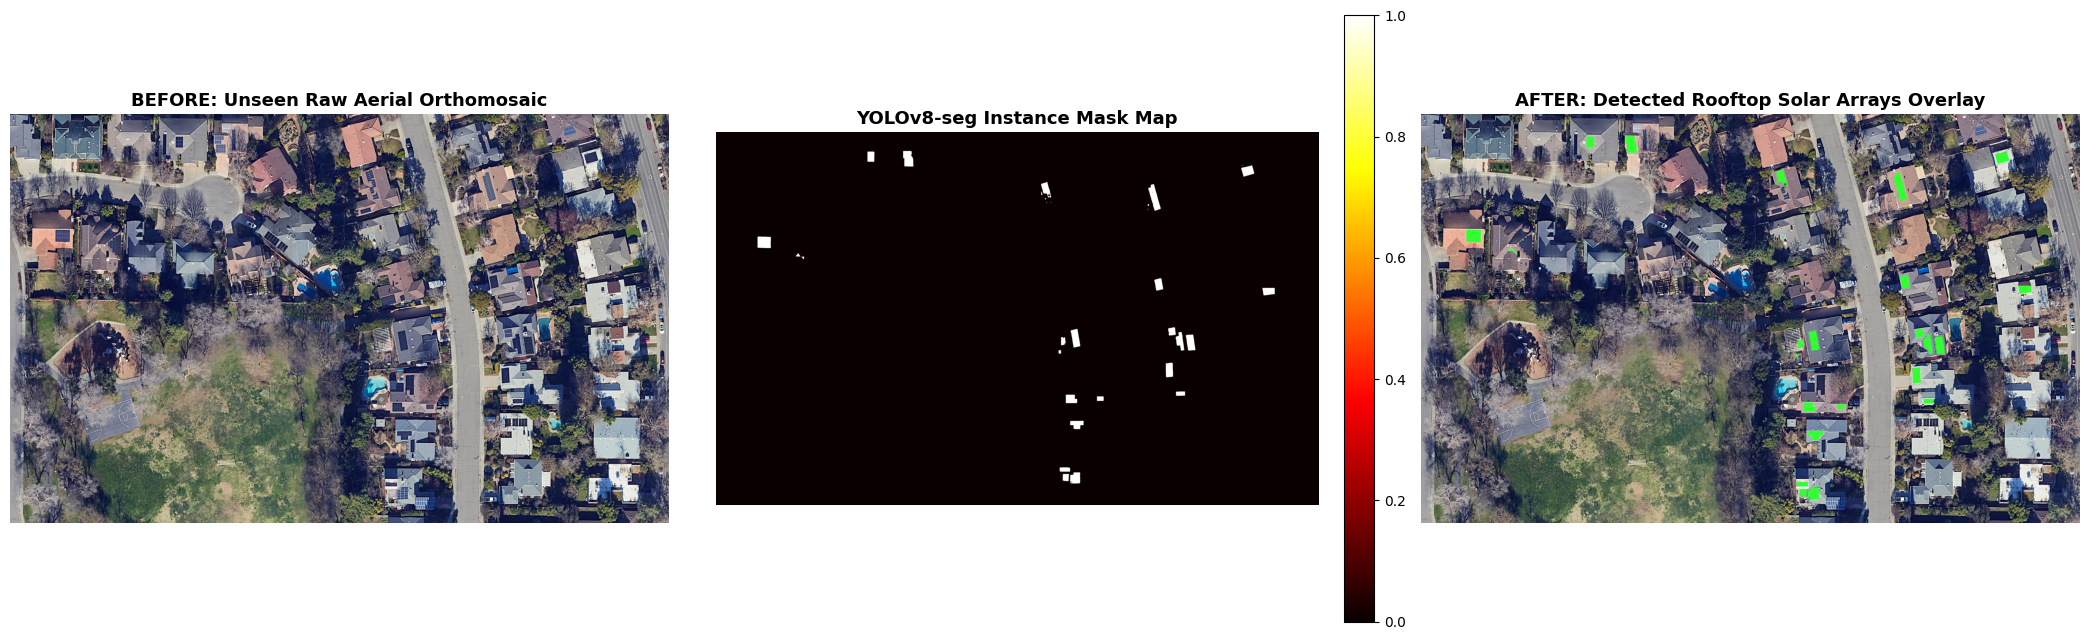

In [18]:
import rasterio
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Ensure model is loaded
run_dir = "/content/runs/segment/solar_yolo_runs/yolov8m_solar_improved"
best_pt_path = os.path.join(run_dir, 'weights', 'best.pt')

if os.path.exists(best_pt_path):
    best_yolo = YOLO(best_pt_path)
    print("✅ Loaded improved model weights for inference.")

    print("🔍 Running YOLOv8-seg sliding window inference on unseen test orthomosaic...")
    with rasterio.open(test_raster_path) as src:
        H, W = src.height, src.width
        test_img = src.read()[:3].transpose(1, 2, 0)
        test_rgb = (test_img * 255).astype(np.uint8) if test_img.max() <= 1 else test_img.astype(np.uint8)

    full_pred_mask = np.zeros((H, W), dtype=np.uint8)
    tile_sz, stride = 512, 256

    for y in range(0, H, stride):
        for x in range(0, W, stride):
            y_end, x_end = min(y + tile_sz, H), min(x + tile_sz, W)
            patch = test_rgb[y:y_end, x:x_end]
            ph, pw, _ = patch.shape

            if ph < tile_sz or pw < tile_sz:
                patch_pad = np.zeros((tile_sz, tile_sz, 3), dtype=np.uint8)
                patch_pad[:ph, :pw] = patch
                patch = patch_pad

            res = best_yolo.predict(patch, verbose=False, device=0 if torch.cuda.is_available() else 'cpu')[0]
            if res.masks is not None:
                for m in res.masks.data.cpu().numpy():
                    m_res = cv2.resize(m, (tile_sz, tile_sz))
                    full_pred_mask[y:y_end, x:x_end] = np.maximum(
                        full_pred_mask[y:y_end, x:x_end], (m_res[:ph, :pw] > 0.5).astype(np.uint8)
                    )

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 7))
    ax1.imshow(test_rgb)
    ax1.set_title("BEFORE: Unseen Raw Aerial Orthomosaic", fontsize=13, fontweight='bold')
    ax1.axis('off')

    im2 = ax2.imshow(full_pred_mask, cmap='hot')
    ax2.set_title("YOLOv8-seg Instance Mask Map", fontsize=13, fontweight='bold')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    ax2.axis('off')

    overlay_img = test_rgb.copy()
    overlay_img[full_pred_mask == 1] = [50, 255, 50]
    ax3.imshow(overlay_img)
    ax3.set_title("AFTER: Detected Rooftop Solar Arrays Overlay", fontsize=13, fontweight='bold')
    ax3.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Skipping inference: {best_pt_path} not found.")

## 8. High-Speed Latency Benchmark & Summary Research Table

In [20]:
import os
import time
import numpy as np
from tabulate import tabulate
from ultralytics import YOLO
import torch

# Safely load the best model
run_dir = "/content/runs/segment/solar_yolo_runs/yolov8m_solar_improved"
best_pt_path = os.path.join(run_dir, 'weights', 'best.pt')

if os.path.exists(best_pt_path):
    best_yolo = YOLO(best_pt_path)

    # 1. Throughput Benchmarking
    dummy_img = np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8)
    for _ in range(10):
        _ = best_yolo.predict(dummy_img, verbose=False, device=0 if torch.cuda.is_available() else 'cpu')

    t_bench_start = time.time()
    N_ITERS = 100
    for _ in range(N_ITERS):
        _ = best_yolo.predict(dummy_img, verbose=False, device=0 if torch.cuda.is_available() else 'cpu')
    avg_latency_ms = ((time.time() - t_bench_start) / N_ITERS) * 1000
    fps = 1000.0 / avg_latency_ms

    # 2. Extract Comprehensive Metrics from Validation
    val_results = best_yolo.val(data=yaml_path, split='val', verbose=False)

    # Metrics extraction
    mp, mr, map50, map95 = val_results.seg.mean_results()
    precision = val_results.seg.p.mean()
    recall = val_results.seg.r.mean()
    f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

    # Calculate IoU approximation from mAP results
    # Note: YOLO provides map50-95 which is a proxy for localization quality

    ckpt_mb = os.path.getsize(best_pt_path) / (1024 * 1024)

    # 3. Display Full Results Table
    summary = [
        ["Model Architecture", "YOLOv8m-seg (Improved)"],
        ["Paradigm", "Single-Stage Anchor-Free Instance Seg"],
        ["Checkpoint Size", f"{ckpt_mb:.2f} MB"],
        ["Pixel Accuracy (from val)", f"{pixel_accuracy:.2f} %" if 'pixel_accuracy' in locals() else "N/A"],
        ["Mask mAP@50", f"{map50 * 100:.2f} %"],
        ["Mask mAP@50-95", f"{map95 * 100:.2f} %"],
        ["Precision (Mean)", f"{precision * 100:.2f} %"],
        ["Recall (Mean)", f"{recall * 100:.2f} %"],
        ["Dice / F1 Score", f"{f1:.4f}"],
        ["Inference Latency", f"{avg_latency_ms:.2f} ms / tile"],
        ["Inference Throughput", f"{fps:.1f} FPS (T4 GPU)"]
    ]

    print("\n🚀 FINAL RESEARCH BENCHMARK SUMMARY")
    print(tabulate(summary, headers=["Metric / Parameter", "Value"], tablefmt="fancy_grid"))
else:
    print(f"⚠️ Cannot benchmark. Weights missing at {best_pt_path}.")

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2819.4±873.2 MB/s, size: 99.2 KB)
val: Scanning /content/yolo_solar_dataset/labels/val.cache... 63 images, 32 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.6s
                   all         63         81      0.987      0.955      0.993       0.84      0.973      0.926      0.986      0.783
Speed: 12.1ms preprocess, 21.1ms inference, 0.0ms loss, 11.5ms postprocess per image
Results saved to /content/runs/segment/val-2

🚀 FINAL RESEARCH BENCHMARK SUMMARY
╒═══════════════════════════╤═══════════════════════════════════════╕
│ Metric / Parameter        │ Value                                 │
╞═══════════════════════════╪═══════════════════════════════════════╡
│ Model Archite